In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\FRINICT\Documents\Anavami and John Class\Simple Linear Regression\study_scores_linear_regression.csv")

In [5]:
df

,Hours_Studied,Score
0,6,65
1,1,15
2,4,45
3,4,45
4,8,85
...,...,...
195,6,65
196,2,25
197,3,35
198,3,35


In [11]:
df.head()

,Hours_Studied,Score
0,6,65
1,1,15
2,4,45
3,4,45
4,8,85


In [13]:
df.tail()

,Hours_Studied,Score
195,6,65
196,2,25
197,3,35
198,3,35
199,9,95


In [7]:
# Check the columns
df.columns

Index(['Hours_Studied', 'Score'], dtype='object')

In [9]:
# Check the datatypes
df.dtypes

Hours_Studied    int64
Score            int64
dtype: object

In [15]:
# Check for missing values
df.isnull().sum()

Hours_Studied    0
Score            0
dtype: int64

In [17]:
# Statistical Summary
df.describe()

,Hours_Studied,Score
count,200.000000,200.000000
mean,5.015000,55.150000
std,2.568611,25.686113
min,1.000000,15.000000
25%,3.000000,35.000000
50%,5.000000,55.000000
75%,7.000000,75.000000
max,9.000000,95.000000


In [19]:
df["Hours_Studied"].describe()

count    200.000000
mean       5.015000
std        2.568611
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max        9.000000
Name: Hours_Studied, dtype: float64

In [21]:
df["Score"].describe()

count    200.000000
mean      55.150000
std       25.686113
min       15.000000
25%       35.000000
50%       55.000000
75%       75.000000
max       95.000000
Name: Score, dtype: float64

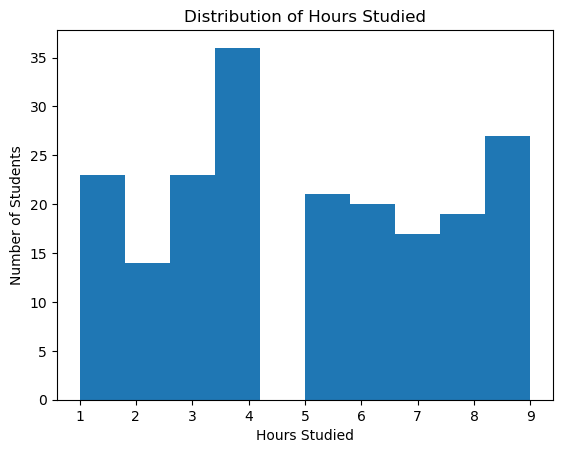

In [25]:
# Checking for the distribution of "Hours_Studied"
plt.hist(df["Hours_Studied"])
plt.xlabel("Hours Studied")
plt.ylabel("Number of Students")
plt.title("Distribution of Hours Studied")
plt.show()

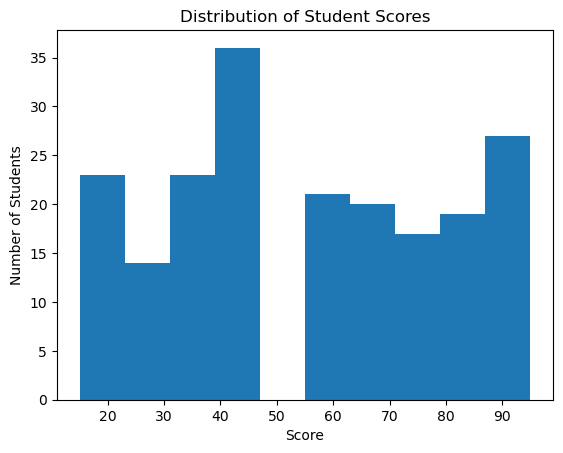

In [27]:
# Checking for the distribution of "Scores"
plt.hist(df["Score"])
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Scores")
plt.show()

In [29]:
# Calculating the correlation between hours studied and score
df["Hours_Studied"].corr(df["Score"])

0.9999999999999981

Correlation measures the strength and direction of a relationship between two numerical variables.

The correlation coefficient ranges from:

$$
-1 \text{ to } +1
$$

### Interpretation

| Correlation | Meaning                        |
| ----------- | ------------------------------ |
| Close to +1 | Strong positive relationship   |
| Close to 0  | Weak or no linear relationship |
| Close to -1 | Strong negative relationship   |

Because our dataset was deliberately generated with a direct linear relationship, we expect a correlation very close to:

```text
+1
```

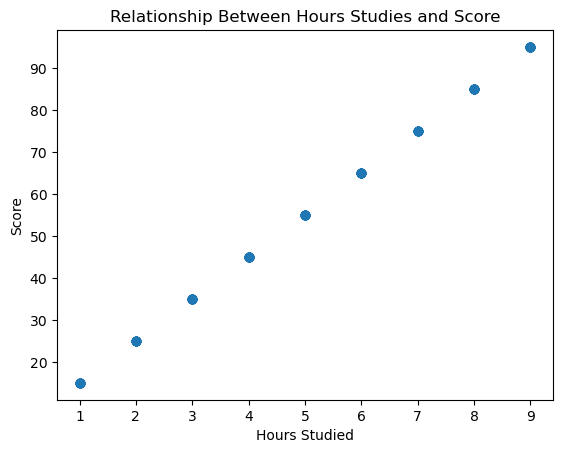

In [36]:
# Visualizing the relationship between both variables
plt.scatter(df["Hours_Studied"], df["Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Relationship Between Hours Studies and Score")
plt.show()

##  Preparing the Data for Machine Learning

Before training our model, we need to identify:

### Feature

The feature is the variable we use to make predictions.

Our feature is:

```text
Hours_Studied
```

We usually represent the feature as `X`.

### Target

The target is the value we want to predict.

Our target is:

```text
Score
```

We represent it as `y`.

Therefore:

```python
X = df[["Hours_Studied"]]
y = df["Score"]
```

Notice the double square brackets around `Hours_Studied`.

We use:

```python
df[["Hours_Studied"]]
```

because `X` should be a DataFrame.

---

In [39]:
X = df[["Hours_Studied"]]
y = df["Score"]

In [41]:
X

,Hours_Studied
0,6
1,1
2,4
3,4
4,8
...,...
195,6
196,2
197,3
198,3


In [43]:
y

0      65
1      15
2      45
3      45
4      85
       ..
195    65
196    25
197    35
198    35
199    95
Name: Score, Length: 200, dtype: int64

In [47]:
# Train_Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
# Training the Linear Regression Model
# Import Linear Regression
from sklearn.linear_model import LinearRegression

In [51]:
#Create the model
model = LinearRegression()

In [53]:
# Train the model
model.fit(X_train, y_train)

LinearRegression()

In [55]:
# Making Predictions
y_pred = model.predict(X_test)

In [61]:
comparison  = pd.DataFrame({
    "Actual Score" : y_test,
    "Predicted Score" : y_pred 
})
comparison.head()

,Actual Score,Predicted Score
95,65,65.0
15,85,85.0
30,25,25.0
158,95,95.0
128,95,95.0


In [67]:
# Making a prediction for a student
student_1 = pd.DataFrame({
    "Hours_Studied" : [7]
})
prediction = model.predict(student_1)
print("Predicted Score:", prediction[0])

Predicted Score: 75.00000000000001


Our model predicted:

```text
Predicted Score: 75
```

This is because:

$$
Score = 5 + (10 \times 7)
$$

$$
Score = 75
$$

---

In [77]:
# Evaluation of the model
# Mean Absolute Error (MAE)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 6.217248937900877e-15


Suppose:

```text
MAE = 3
```

This means that the model's predictions are off by approximately **3 points on average**.

### Important

For MAE:

> **Lower is better.**

---

In [79]:
# Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 7.825500179792437e-29


MSE gives greater punishment to large errors because the errors are squared.

### Important

For MSE:

> **Lower is better.**

---

In [82]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 8.846185720293485e-15


RMSE is useful because it is expressed in the same unit as the target variable.

Since our target is `Score`, RMSE is measured in **score points**.

For example:

```text
RMSE = 4
```

means the model's prediction error is roughly 4 score points, with larger errors receiving more weight.

### Important

For RMSE:

> **Lower is better.**

---

In [85]:
# R² Score
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 1.0


R² is commonly interpreted as a value between 0 and 1 for many regression problems.

For example:

```text
R² = 0.80
```

can be interpreted as the model explaining approximately **80% of the variation** in the target in that evaluation setting.

An R² closer to 1 generally indicates a better fit.

### Important

For R²:

> **Higher is better.**

---

## Comparing the Four Metrics

| Metric | What it tells us                                    | Better value |
| ------ | --------------------------------------------------- | ------------ |
| MAE    | Average absolute prediction error                   | Lower        |
| MSE    | Average squared prediction error                    | Lower        |
| RMSE   | Typical prediction error, emphasizing larger errors | Lower        |
| R²     | Proportion of target variation explained by model   | Higher       |

---

In [89]:
# from sklearn.metrics import (
#     mean_absolute_error,
#     mean_squared_error,
#     r2_score
# )
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 6.217248937900877e-15
MSE: 7.825500179792437e-29
RMSE: 8.846185720293485e-15
R²: 1.0


## Understanding the Regression Line

The regression line is represented by:

$$
y = b_0 + b_1x
$$
or
$$
y = c + m_1x
$$
or 
$$
y = m_1x + c 
$$

For our model:

$$
Score = 5 + 10(Hours\_Studied)
$$

There are two important parts.

---

In [96]:
# Intercept
model.intercept_

4.999999999999986

## Understanding the Intercept

The intercept is:

```python
model.intercept_
```

Our intercept is approximately:

```text
5
```

The intercept tells us the predicted value of the target when the feature is zero.

Therefore:

> If `Hours_Studied = 0`, the model predicts a score of 5.

Mathematically:

$$
Score = 5 + 10(0)
$$

$$
Score = 5
$$

### Important Note

The intercept does not always have a meaningful real-world interpretation.

In our example, a student studying zero hours may not actually score exactly 5.

The intercept is primarily part of the mathematical equation that defines the regression line.

---

In [99]:
# Slope
model.coef_

array([10.])

## Understanding the Slope

The slope is:

```python
model.coef_
```

Our slope is approximately:

```text
10
```

This is one of the most important values in Linear Regression.

The slope tells us how much the predicted target changes when the feature increases by one unit.

Our slope is 10.

Therefore:

> For every additional hour studied, the predicted score increases by approximately 10 points.

For example:

### 1 hour

$$
Score = 5 + 10(1) = 15
$$

### 2 hours

$$
Score = 5 + 10(2) = 25
$$

### 5 hours

$$
Score = 5 + 10(5) = 55
$$

### 8 hours

$$
Score = 5 + 10(8) = 85
$$

---

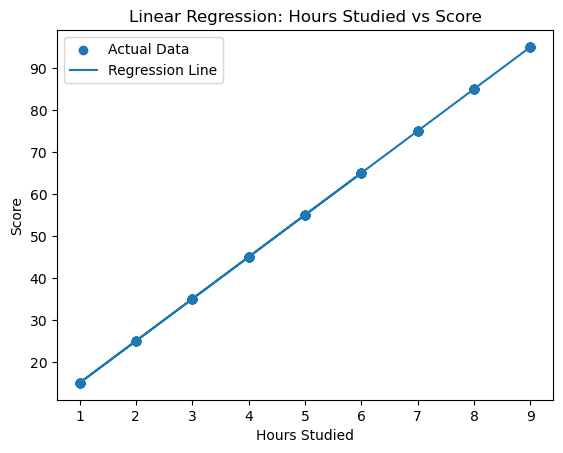

In [102]:
# Plotting our Regression Line
plt.scatter(X, y, label="Actual Data")

plt.plot(X, model.predict(X), label="Regression Line")

plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Linear Regression: Hours Studied vs Score")

plt.legend()

plt.show()

The scatter points represent the students.

The straight line represents the relationship learned by the Linear Regression model.

---

##  **Understanding the Complete Workflow**

At this point, we have completed the basic Machine Learning workflow.

The process can be summarized as:

```text
                 DATA
                   ↓
          UNDERSTAND THE DATA
                   ↓
                  EDA
                   ↓
       VISUALIZE THE RELATIONSHIP
                   ↓
            DEFINE X AND y
                   ↓
          SPLIT THE DATA
             ↙          ↘
        Training       Testing
             ↓            ↓
          TRAIN MODEL     |
             ↓            |
          PREDICT ────────┘
             ↓
       EVALUATE MODEL
             ↓
      INTERPRET RESULTS
```

---